<a href="https://colab.research.google.com/github/guanghen/ResNet50_Image_Classification/blob/main/Quick_Test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import os

# get the repository
REPO_URL = "https://github.com/guanghen/ResNet50_Image_Classification.git"
REPO_NAME = "ResNet50_Image_Classification"


if not os.path.exists(REPO_NAME):
    os.system(f"git clone {REPO_URL}")

# Change the Diretory to the repositor
os.chdir(REPO_NAME)
print("Environment is ready")

Environment is ready


In [3]:
#Load the model
import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image
import matplotlib.pyplot as plt
import random

# The categories we tried to predict
classes = ['bicycle', 'cat', 'banana', 'bed', 'traffic light']
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_path = 'resnet50_coco_model.pth'
model_url = "https://github.com/guanghen/ResNet50_Image_Classification/releases/download/v1.0/resnet50_coco_model.pth"

if not os.path.exists(model_path):
    torch.hub.download_url_to_file(model_url, model_path)
    print("Model have been downloaded")

# Initialize the model and load it
model = models.resnet50(weights=None)
model.fc = nn.Linear(model.fc.in_features, len(classes))
model.load_state_dict(torch.load(model_path, map_location=device, weights_only=False))
model.to(device)
model.eval()

# image preprocessing
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

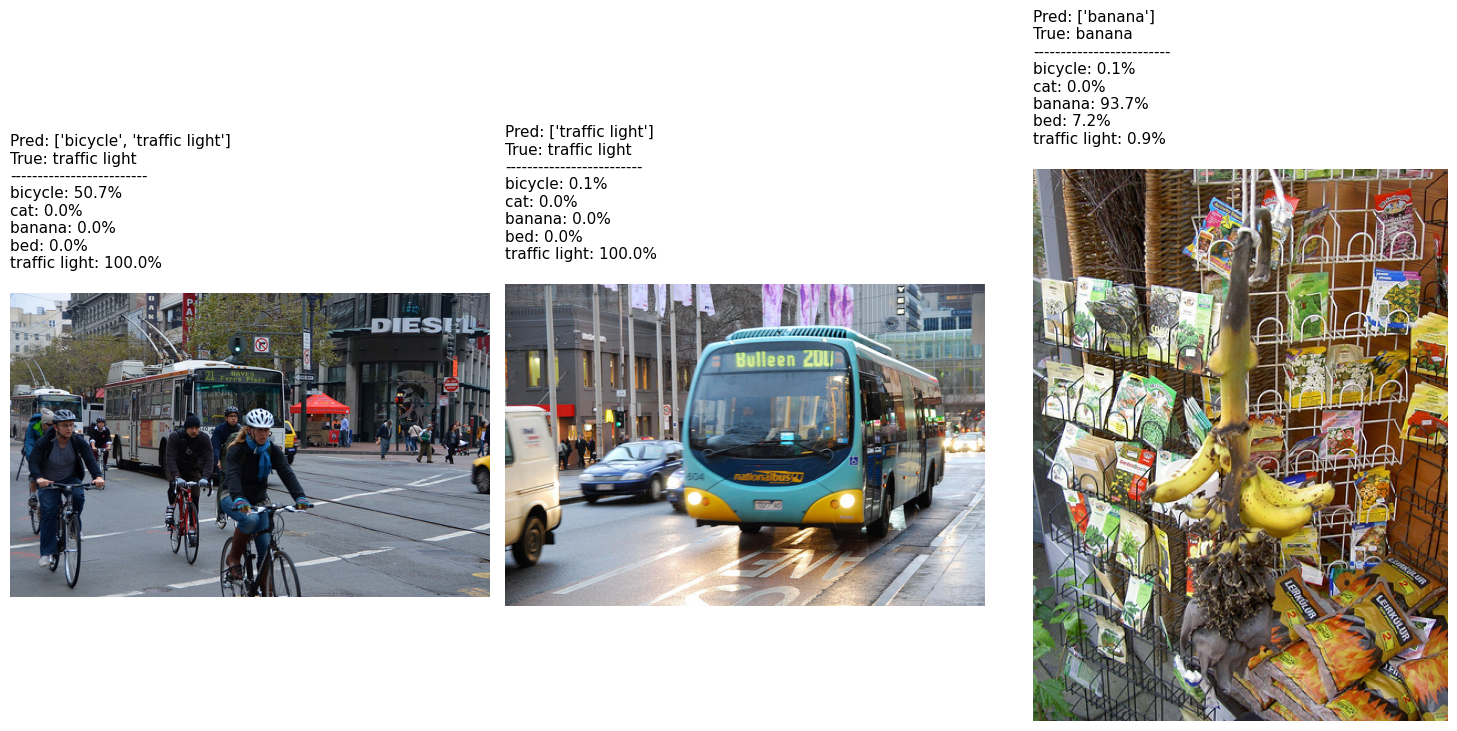

In [4]:
#Randomly pick images and predict
test_dir = './test_examples'

# get all the image name from text_examples diretory
all_images = [f for f in os.listdir(test_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

# randomly pick 3 images
if len(all_images) >= 3:
    selected_images = random.sample(all_images, 3)
else:
    selected_images = all_images


fig, axes = plt.subplots(1, len(selected_images), figsize=(15, 7))

# if only one image exist, convert axes into list
if len(selected_images) == 1:
    axes = [axes]

for i, img_name in enumerate(selected_images):
    # read the images
    img_path = os.path.join(test_dir, img_name)
    img = Image.open(img_path).convert("RGB")
    true_label = img_name.split('_')[0]

    # prediction
    input_tensor = transform(img).unsqueeze(0).to(device)
    with torch.no_grad():
        output = model(input_tensor)
        probs = torch.sigmoid(output)[0] # get the sigmoid rate from 5 categories

        # if the sigmoid is greater than 5, pick it as final predict
        pred_labels = [classes[j] for j, score in enumerate(probs) if score > 0.5]
        if not pred_labels:
            pred_labels = ["None"]


    title_text = f"Pred: {pred_labels}\n" + f"True: {true_label}\n" + "-"*25 + "\n"

    #Shows the prediction rate of 5 categories
    for j, class_name in enumerate(classes):
        prob_value = probs[j].item() * 100
        title_text += f"{class_name}: {prob_value:.1f}%\n"


    axes[i].imshow(img)
    axes[i].set_title(title_text, loc='left', fontsize=11)
    axes[i].axis('off')


plt.tight_layout()
plt.show()